# Data Investigation & Preprocessing

## Feature Descriptions

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("../data/sd`ss_dr18.csv")

df.columns

Index(['objid', 'specobjid', 'ra', 'dec', 'u', 'g', 'r', 'i', 'z', 'run',
       'rerun', 'camcol', 'field', 'plate', 'mjd', 'fiberid', 'petroRad_u',
       'petroRad_g', 'petroRad_i', 'petroRad_r', 'petroRad_z', 'petroFlux_u',
       'petroFlux_g', 'petroFlux_i', 'petroFlux_r', 'petroFlux_z',
       'petroR50_u', 'petroR50_g', 'petroR50_i', 'petroR50_r', 'petroR50_z',
       'psfMag_u', 'psfMag_r', 'psfMag_g', 'psfMag_i', 'psfMag_z', 'expAB_u',
       'expAB_g', 'expAB_r', 'expAB_i', 'expAB_z', 'redshift', 'class'],
      dtype='object')

The following are identification columns:

    objid = Unique SDSS object ID
    specobjid = Unique spectroscopy observation ID
    run = Imaging scan run number
    rerun = Reprocessing version
    camcol = Camera column used
    field = Sky field number
    plate = Spectroscopic plate ID
    mjd = Modified Julian Date of observation
    fiberid = Fiber number on spectroscopic plate

The following are position columns:

    ra = Right ascension (J2000)
    dec = Declination (J2000)

The following are photometric columns:

    u = SDSS u-band magnitude (ultraviolet)
    g = SDSS g-band magnitude (green)
    r = SDSS r-band magnitude (red)
    i = SDSS i-band magnitude (near-infrared)
    z = SDSS z-band magnitude (infrared)
    
PSF = Point Spread Function, which describes how a point source of light (like a star) is spread out in an image due to atmospheric and instrumental effects. 
The following are point spread function (PSF) magnitude columns:

    psfmag_u = PSF magnitude in u-band
    psfmag_g = PSF magnitude in g-band
    psfmag_r = PSF magnitude in r-band
    psfmag_i = PSF magnitude in i-band
    psfmag_z = PSF magnitude in z-band

Petrosian radius is a measure of the size of an astronomical object, defined as the radius at which the surface brightness of the object drops to a certain fraction of its average surface brightness within that radius.
The following describe apparent size/radius of the object:

    petroRad_u = Petrosian radius in u-band
    petroRad_g = Petrosian radius in g-band
    petroRad_r = Petrosian radius in r-band
    petroRad_i = Petrosian radius in i-band
    petroRad_z = Petrosian radius in z-band

The following describe apparent size/radius of the object in flux:

    pertroFlux_u = Petrosian flux in u-band
    pertroFlux_g = Petrosian flux in g-band
    pertroFlux_r = Petrosian flux in r-band
    pertroFlux_i = Petrosian flux in i-band
    pertroFlux_z = Petrosian flux in z-band

The following show radius of 50% light in the object:

    petroR50_u = Petrosian radius containing 50% of the flux in u-band
    petroR50_g = Petrosian radius containing 50% of the flux in g-band
    petroR50_r = Petrosian radius containing 50% of the flux in r-band
    petroR50_i = Petrosian radius containing 50% of the flux in i-band
    petroR50_z = Petrosian radius containing 50% of the flux in z-band

The following show ratio of minor axis to major axis of the object:

    expAB_u = Ratio of minor axis to major axis in u-band
    expAB_g = Ratio of minor axis to major axis in g-band
    expAB_r = Ratio of minor axis to major axis in r-band
    expAB_i = Ratio of minor axis to major axis in i-band
    expAB_z = Ratio of minor axis to major axis in z-band

Redshift is a measure of how much the wavelength of light from an object has been stretched due to the expansion of the universe. It is often used to determine the distance to astronomical objects.

    redshift = Redshift of the object

    class = Spectral classification of the object (e.g., STAR, GALAXY, QSO)

Identification and observational metadata columns will be excluded from model training due to their lack of physical relevance to stellar object classification. Features such as object IDs, observation run numbers, plate numbers, and fiber identifiers uniquely identify observations but do not describe intrinsic astronomical properties of the observed objects.

Positional coordinates (ra, dec) will also be excluded, as sky location alone is not expected to directly determine object class.

Redshift will additionally be excluded from initial model training despite its strong correlation with object type. Since redshift is often used directly in astronomical classification pipelines, retaining it could allow the model to rely too heavily on a single feature rather than learning broader photometric and structural relationships between stellar object classes. Excluding redshift enables a more meaningful evaluation of how effectively the models can classify objects using observational characteristics alone.

The remaining photometric, structural, and spectroscopic features will be retained, as they contain physically meaningful information related to brightness, morphology, color distribution, and redshift characteristics that are relevant for distinguishing between stellar object classes

In [29]:
drop_cols = [
    'objid', 'specobjid', 'run', 'rerun', 'camcol',
    'field', 'plate', 'mjd', 'fiberid',
    'ra', 'dec',
    'redshift'
]

df = df.drop(columns=drop_cols)

## Missing Values

In [65]:
df.isnull().sum()

u              0
g              0
r              0
i              0
z              0
petroRad_u     0
petroRad_g     0
petroRad_i     0
petroRad_r     0
petroRad_z     0
petroFlux_u    0
petroFlux_g    0
petroFlux_i    0
petroFlux_r    0
petroFlux_z    0
petroR50_u     0
petroR50_g     0
petroR50_i     0
petroR50_r     0
petroR50_z     0
psfMag_u       0
psfMag_r       0
psfMag_g       0
psfMag_i       0
psfMag_z       0
expAB_u        0
expAB_g        0
expAB_r        0
expAB_i        0
expAB_z        0
class          0
dtype: int64

The dataset contains no missing values across the selected features, therefore no imputation or row removal is required.

## Class Distribution

Class distribution analysis is important for determining whether the
dataset is balanced across stellar object categories. Significant class
imbalance may influence model bias and affect classification performance,
particularly for underrepresented classes.

(100000, 31)
class
GALAXY    52343
STAR      37232
QSO       10425
Name: count, dtype: int64


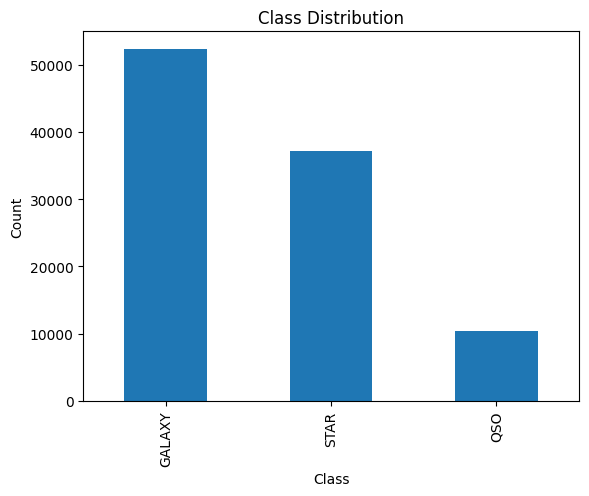

In [66]:
df['class'].value_counts()

print(df.shape)
print(df['class'].value_counts())

df['class'].value_counts().plot(kind='bar')

plt.title("Class Distribution")
plt.xlabel("Class")
plt.ylabel("Count")
plt.savefig("../plots/class_distribution.png", dpi=300, bbox_inches='tight')

plt.show()

Dataset exhibits moderate class imbalance, with GALAXY objects representing the majority class and QSO objects representing the minority class. This imbalance is important when evaluating model performance, particularly for recall and precision metrics on minority classes.

## Correlation Analysis

Correlation analysis was performed to examine linear relationships between the retained numerical features in the SDSS DR18 dataset. This step helps identify groups of variables that may contain overlapping information, which is important for understanding feature redundancy before model training.

In [67]:
corr_matrix = df.corr(numeric_only=True)

corr_matrix

,u,g,r,i,z,petroRad_u,petroRad_g,petroRad_i,petroRad_r,petroRad_z,...,psfMag_u,psfMag_r,psfMag_g,psfMag_i,psfMag_z,expAB_u,expAB_g,expAB_r,expAB_i,expAB_z
u,1.000000,0.841336,0.688421,0.020582,0.008688,-0.047860,-0.155501,-0.150395,-0.160316,-0.110738,...,0.629102,0.602685,0.644853,0.020900,0.008845,-0.142524,-0.063311,-0.060047,-0.002875,-0.004592
g,0.841336,1.000000,0.955252,0.031714,0.018418,-0.146411,-0.284235,-0.264529,-0.284066,-0.203686,...,0.374871,0.673962,0.605901,0.025461,0.014848,-0.146246,-0.022083,-0.035700,-0.003109,-0.002797
r,0.688421,0.955252,1.000000,0.033908,0.020825,-0.193166,-0.339863,-0.315950,-0.343968,-0.246838,...,0.197574,0.624367,0.488191,0.024041,0.015259,-0.145159,-0.005691,-0.025105,-0.003292,-0.002343
i,0.020582,0.031714,0.033908,1.000000,0.577652,-0.007820,-0.014905,-0.012199,-0.015385,-0.009402,...,0.000428,0.016253,0.011096,0.999436,0.577397,-0.005273,0.003103,0.003158,0.999249,0.576910
z,0.008688,0.018418,0.020825,0.577652,1.000000,-0.007145,-0.008359,-0.006625,-0.008456,-0.005938,...,-0.002823,0.009200,0.005310,0.577278,0.999824,-0.005738,0.004113,0.003735,0.577189,0.999699
petroRad_u,-0.047860,-0.146411,-0.193166,-0.007820,-0.007145,1.000000,0.371071,0.337820,0.379233,0.283812,...,0.263164,0.134547,0.188947,0.004516,-0.000232,0.006502,-0.065251,-0.044373,0.000040,-0.001699
petroRad_g,-0.155501,-0.284235,-0.339863,-0.014905,-0.008359,0.371071,1.000000,0.683884,0.784206,0.564519,...,0.466181,0.295511,0.372119,0.009192,0.005151,0.014269,-0.128750,-0.087093,-0.001390,0.000918
petroRad_i,-0.150395,-0.264529,-0.315950,-0.012199,-0.006625,0.337820,0.683884,1.000000,0.752157,0.555198,...,0.427241,0.275316,0.343674,0.010387,0.005988,0.020359,-0.113030,-0.076154,0.000542,0.001955
petroRad_r,-0.160316,-0.284066,-0.343968,-0.015385,-0.008456,0.379233,0.784206,0.752157,1.000000,0.609796,...,0.493508,0.325190,0.404141,0.010118,0.005665,0.018657,-0.130617,-0.086359,-0.001683,0.000751
petroRad_z,-0.110738,-0.203686,-0.246838,-0.009402,-0.005938,0.283812,0.564519,0.555198,0.609796,1.000000,...,0.383995,0.264024,0.320088,0.010241,0.005117,0.016695,-0.098263,-0.064228,0.000554,0.001004


The correlation matrix contains many pairwise comparisons, making it difficult to interpret directly as a numerical table. For this reason, the matrix is visualized as a heatmap to make strong positive correlations, negative correlations, and feature clusters easier to identify.

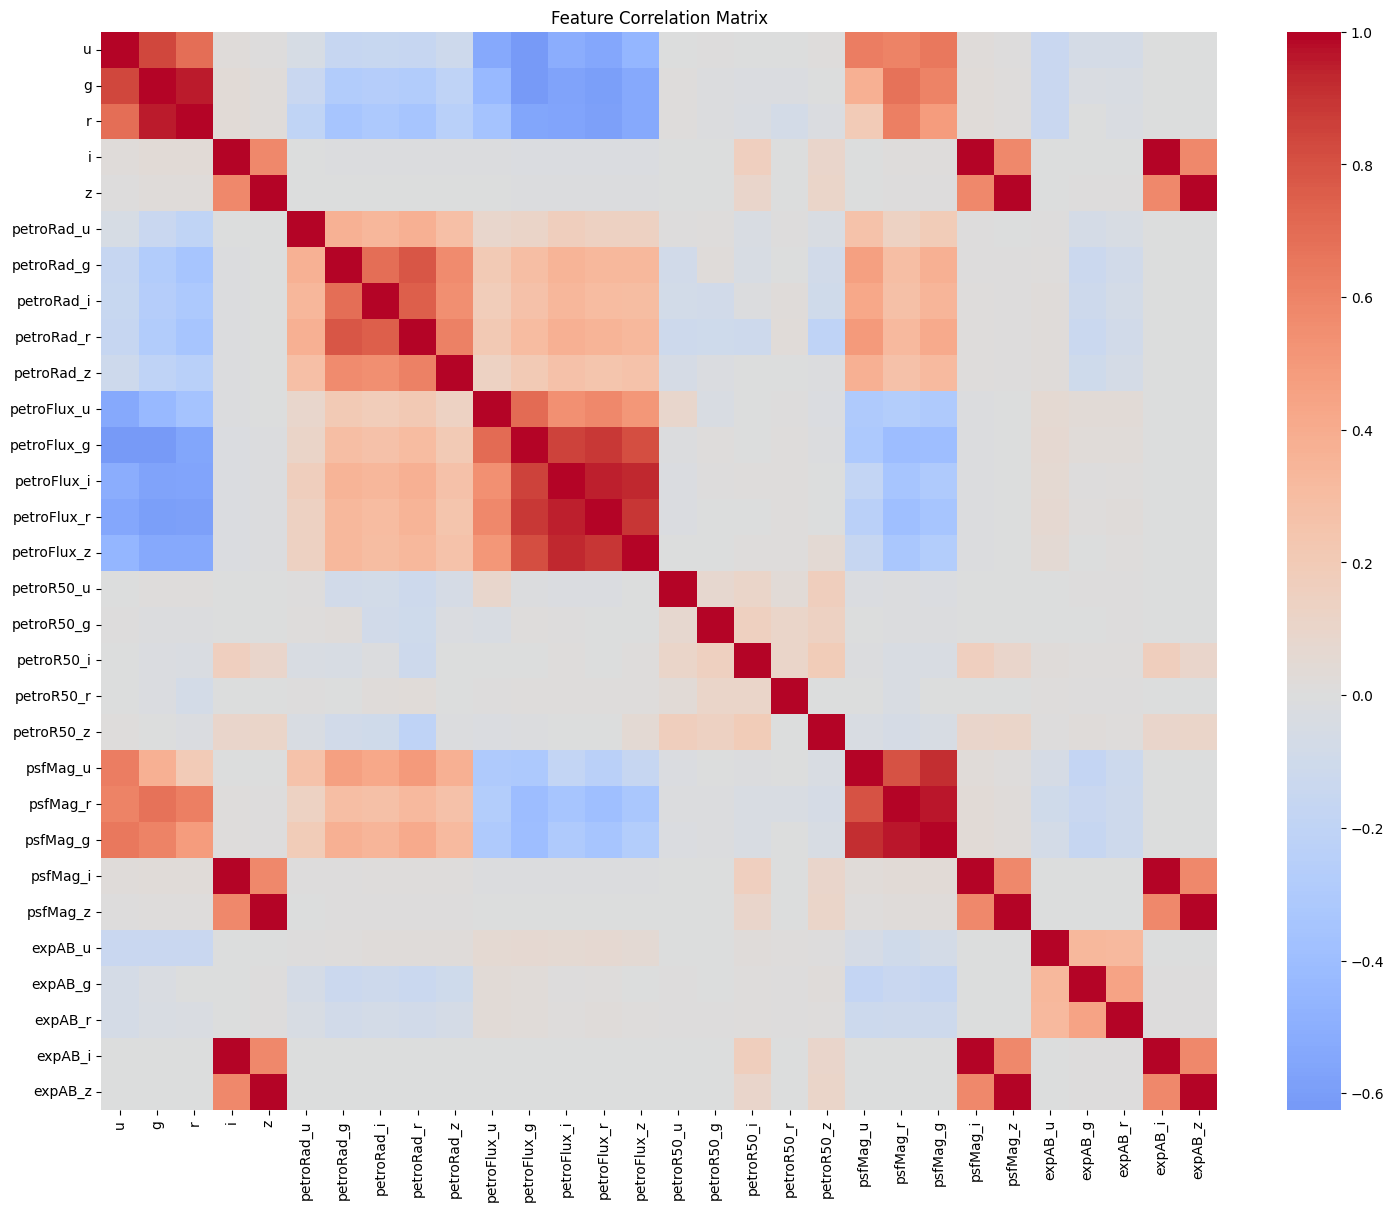

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(18, 14))

sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0
)

plt.title("Feature Correlation Matrix")
plt.savefig("../plots/correlation_heatmap.png", dpi=300, bbox_inches='tight')

plt.show()

Correlation coefficients range from -1 to 1.

Values close to:

    1 indicate strong positive correlation (red)
    0 indicate weak or no correlation (white)
    -1 indicate strong negative correlation (blue)

Strong correlations may suggest partially redundant information between features.

The heatmap shows strong correlations between neighbouring photometric bands, PSF magnitude measurements, and Petrosian flux features. These relationships are physically expected because nearby wavelength bands often capture related brightness information from the same astronomical objects.

Some near-perfect correlations are also visible, particularly among certain i-band and z-band measurements. These may indicate feature redundancy, where multiple variables provide very similar information.

Negative correlations between magnitude and flux measurements are physically consistent with the astronomical magnitude scale, where lower magnitude values correspond to brighter objects with higher flux.

In [71]:
import numpy as np

corr_pairs = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

strong_corr = (
    corr_pairs
    .stack()
    .sort_values(key=abs, ascending=False)
)

strong_corr.head(20)

z            psfMag_z       0.999824
psfMag_z     expAB_z        0.999707
z            expAB_z        0.999699
i            psfMag_i       0.999436
             expAB_i        0.999249
psfMag_i     expAB_i        0.999127
psfMag_r     psfMag_g       0.964144
g            r              0.955252
petroFlux_i  petroFlux_r    0.947490
             petroFlux_z    0.929760
psfMag_u     psfMag_g       0.913943
petroFlux_r  petroFlux_z    0.898146
petroFlux_g  petroFlux_r    0.884323
             petroFlux_i    0.851235
u            g              0.841336
petroFlux_g  petroFlux_z    0.809793
psfMag_u     psfMag_r       0.802526
petroRad_g   petroRad_r     0.784206
petroRad_i   petroRad_r     0.752157
petroFlux_u  petroFlux_g    0.703450
dtype: float64

The strongest correlations confirm the patterns observed in the heatmap. Several i-band and z-band variables show correlations near 1.0, suggesting substantial feature redundancy. Strong relationships are also present between neighbouring photometric bands, PSF magnitude features, and Petrosian flux measurements.

Overall, the correlation analysis shows that many retained features contain meaningful physical relationships, while also identifying highly redundant feature groups that may be important to consider during later feature selection and model interpretation.

## Feature Distribution